In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv('train.csv',usecols=['Age', 'Fare', 'Survived'])

In [6]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
# droping all missing values row 
df.dropna(inplace=True)

In [10]:
df.shape

(714, 3)

In [8]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [11]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [15]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [17]:
clf = DecisionTreeClassifier()

In [18]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [19]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [20]:
# cross_val_score for validataion
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6275430359937402)

# applying Descretizer

In [30]:
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile',quantile_method='averaged_inverted_cdf')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile',quantile_method='averaged_inverted_cdf')

In [31]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [32]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [34]:
trf.named_transformers_['first'].n_bins_
# this will tell how many bin will created

array([10])

In [36]:
# to see bins range
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [38]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [53]:
output.head(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
328,31.0,5.0,20.5250,5.0,"(28.5, 32.0]","(15.75, 26.0]"
73,26.0,4.0,14.4542,4.0,"(25.0, 28.5]","(13.0, 15.75]"
253,30.0,5.0,16.1000,5.0,"(28.5, 32.0]","(15.75, 26.0]"
719,33.0,6.0,7.7750,1.0,"(32.0, 36.0]","(7.75, 7.896]"
666,25.0,4.0,13.0000,4.0,"(22.0, 25.0]","(9.225, 13.0]"


In [39]:
output['age_labels']= pd.cut(x=X_train['Age'], bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels']= pd.cut(x=X_train['Fare'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [54]:
output.head(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
328,31.0,5.0,20.5250,5.0,"(28.5, 32.0]","(15.75, 26.0]"
73,26.0,4.0,14.4542,4.0,"(25.0, 28.5]","(13.0, 15.75]"
253,30.0,5.0,16.1000,5.0,"(28.5, 32.0]","(15.75, 26.0]"
719,33.0,6.0,7.7750,1.0,"(32.0, 36.0]","(7.75, 7.896]"
666,25.0,4.0,13.0000,4.0,"(22.0, 25.0]","(9.225, 13.0]"


In [41]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [43]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [45]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6247261345852895)

# function that take input as bins and strategy and apply kBinsDiscretizer

In [63]:
def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy=strategy,quantile_method='averaged_inverted_cdf')
    kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy=strategy,quantile_method='averaged_inverted_cdf')

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)

    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title('after')

    plt.show()

0.6387323943661971


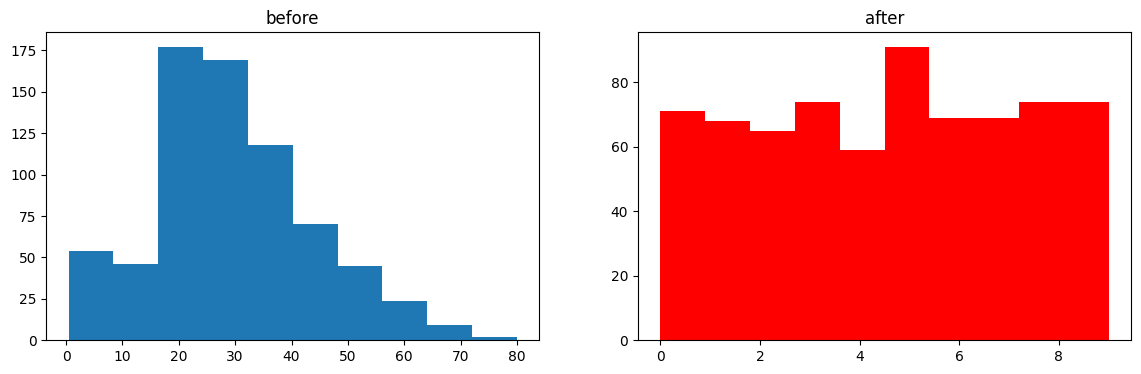

In [64]:
discretize(10,'quantile')

0.6359154929577465


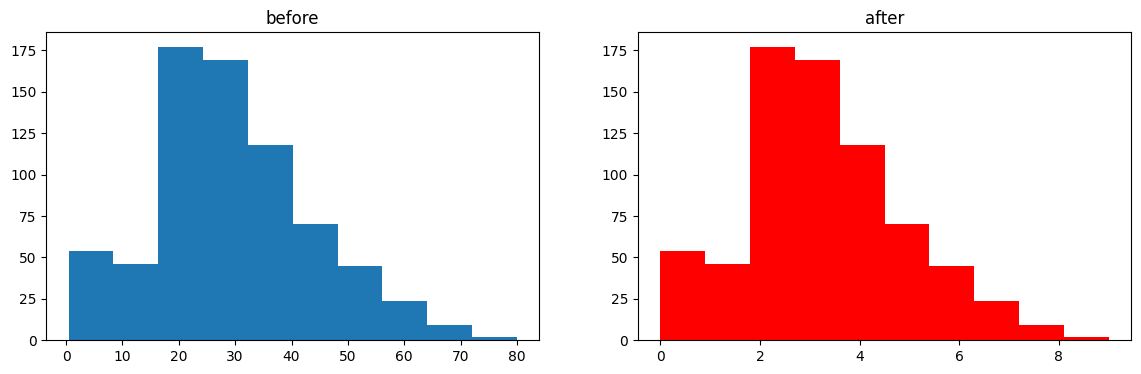

In [65]:
discretize(10,'uniform')

In [66]:
discretize(10,'kmean')

InvalidParameterError: The 'strategy' parameter of KBinsDiscretizer must be a str among {'quantile', 'kmeans', 'uniform'}. Got 'kmean' instead.